# Zero-Shot Prompt Analysis — Dataset-Specific Prompts
**EEEM068 Applied Machine Learning — Member 1: Nikolas**

Evaluates each dataset-specific CLIP prompt individually on the test set, computes mean/variance of accuracy where applicable (≥2 prompts), and produces comparison plots across all 9 datasets.

Uses **dataset-specific prompts** from CLIP paper Appendix A (as instructed by tutor).


In [1]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00


In [2]:
import os, json, re, shutil, zipfile, time
import numpy as np
import torch
import clip
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


class OxfordPetsDataset(Dataset):
    def __init__(self, img_dir, classes, folder_map, transform=None):
        self.transform = transform
        self.classes   = classes
        folder_to_idx = {}
        for folder_key, readable in folder_map.items():
            if readable in classes:
                folder_to_idx[folder_key.lower()] = classes.index(readable)
        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith('.jpg'): continue
            stem = os.path.splitext(fname)[0]
            folder_name = re.sub(r'_\d+$', '', stem).lower()
            if folder_name in folder_to_idx:
                self.samples.append((os.path.join(img_dir, fname), folder_to_idx[folder_name]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img) if self.transform else img, label

class Flowers102Dataset(Dataset):
    def __init__(self, img_dir, samples, transform=None):
        self.img_dir, self.samples, self.transform = img_dir, samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.transform(img) if self.transform else img, label

class FGVCAircraftDataset(Dataset):
    def __init__(self, img_dir, samples, transform=None):
        self.img_dir, self.samples, self.transform = img_dir, samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.transform(img) if self.transform else img, label

class StanfordCarsDataset(Dataset):
    def __init__(self, img_dir, samples, transform=None):
        self.img_dir, self.samples, self.transform = img_dir, samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.transform(img) if self.transform else img, label

class UCF101Dataset(Dataset):
    def __init__(self, img_dir, samples, transform=None):
        self.img_dir, self.samples, self.transform = img_dir, samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.transform(img) if self.transform else img, label

class Food101Dataset(Dataset):
    def __init__(self, img_dir, samples, transform=None):
        self.img_dir, self.samples, self.transform = img_dir, samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.transform(img) if self.transform else img, label

print("Custom Dataset classes defined.")


Using device: cuda
Custom Dataset classes defined.


## Zero-Shot Evaluation Functions

In [3]:
def zeroshot_classifier(classnames, templates, model, device):
    with torch.no_grad():
        zeroshot_weights = []
        for classname in classnames:
            texts = [t.format(classname) for t in templates]
            tokens = clip.tokenize(texts).to(device)
            class_embeddings = model.encode_text(tokens)
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            class_embedding = class_embeddings.mean(dim=0)
            class_embedding /= class_embedding.norm()
            zeroshot_weights.append(class_embedding)
        zeroshot_weights = torch.stack(zeroshot_weights, dim=1).to(device)
    return zeroshot_weights

def evaluate(loader, model, zeroshot_weights, device):
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            logits = 100.0 * image_features @ zeroshot_weights
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

print("zeroshot_classifier and evaluate defined.")


zeroshot_classifier and evaluate defined.


## Dataset-Specific Prompt Templates (CLIP Paper Appendix A)

In [4]:
PROMPTS_BY_DATASET = {

    'eurosat': [
        'satellite imagery of {}.', 'aerial imagery of {}.', 'satellite photo of {}.',
        'aerial photo of {}.', 'satellite view of {}.', 'aerial view of {}.',
        'satellite imagery of a {}.', 'aerial imagery of a {}.', 'satellite photo of a {}.',
        'aerial photo of a {}.', 'satellite view of a {}.', 'aerial view of a {}.',
        'satellite imagery of the {}.', 'aerial imagery of the {}.', 'satellite photo of the {}.',
        'aerial photo of the {}.', 'satellite view of the {}.', 'aerial view of the {}.',
    ],

    'caltech-101': [
        'a photo of a {}.', 'a photo of the {}.', 'a painting of a {}.',
        'a painting of the {}.', 'a plastic {}.', 'the plastic {}.',
        'a sculpture of a {}.', 'a sculpture of the {}.', 'a sketch of a {}.',
        'a sketch of the {}.', 'a tattoo of a {}.', 'a tattoo of the {}.',
        'a toy {}.', 'the toy {}.', 'a rendition of a {}.', 'a rendition of the {}.',
        'a embroidered {}.', 'the embroidered {}.', 'a cartoon {}.', 'the cartoon {}.',
        'a {} in a video game.', 'the {} in a video game.', 'a plushie {}.', 'the plushie {}.',
        'a origami {}.', 'the origami {}.', 'art of a {}.', 'art of the {}.',
        'graffiti of a {}.', 'graffiti of the {}.', 'a drawing of a {}.', 'a drawing of the {}.',
        'a doodle of a {}.', 'a doodle of the {}.',
    ],

    'oxford_pets': ['a photo of a {}, a type of pet.'],

    'dtd': [
        'a photo of a {} texture.', 'a photo of a {} pattern.',
        'a photo of a {} thing.', 'a photo of a {} object.',
        'a photo of the {} texture.', 'a photo of the {} pattern.',
        'a photo of the {} thing.', 'a photo of the {} object.',
    ],

    'flowers102': ['a photo of a {}, a type of flower.'],

    'food101': ['a photo of {}, a type of food.'],

    'fgvc_aircraft': [
        'a photo of a {}, a type of aircraft.',
        'a photo of the {}, a type of aircraft.',
    ],

    'stanford_cars': [
        'a photo of a {}.', 'a photo of the {}.', 'a photo of my {}.',
        'i love my {}!', 'a photo of my dirty {}.', 'a photo of my clean {}.',
        'a photo of my new {}.', 'a photo of my old {}.',
    ],

    'ucf101': [
        'a photo of a person {}.', 'a video of a person {}.', 'a example of a person {}.',
        'a demonstration of a person {}.', 'a photo of the person {}.', 'a video of the person {}.',
        'a example of the person {}.', 'a demonstration of the person {}.',
        'a photo of a person using {}.', 'a video of a person using {}.',
        'a example of a person using {}.', 'a demonstration of a person using {}.',
        'a photo of the person using {}.', 'a video of the person using {}.',
        'a example of the person using {}.', 'a demonstration of the person using {}.',
        'a photo of a person doing {}.', 'a video of a person doing {}.',
        'a example of a person doing {}.', 'a demonstration of a person doing {}.',
        'a photo of the person doing {}.', 'a video of the person doing {}.',
        'a example of the person doing {}.', 'a demonstration of the person doing {}.',
        'a photo of a person during {}.', 'a video of a person during {}.',
        'a example of a person during {}.', 'a demonstration of a person during {}.',
        'a photo of the person during {}.', 'a video of the person during {}.',
        'a example of the person during {}.', 'a demonstration of the person during {}.',
        'a photo of a person performing {}.', 'a video of a person performing {}.',
        'a example of a person performing {}.', 'a demonstration of a person performing {}.',
        'a photo of the person performing {}.', 'a video of the person performing {}.',
        'a example of the person performing {}.', 'a demonstration of the person performing {}.',
        'a photo of a person practicing {}.', 'a video of a person practicing {}.',
        'a example of a person practicing {}.', 'a demonstration of a person practicing {}.',
        'a photo of the person practicing {}.', 'a video of the person practicing {}.',
        'a example of the person practicing {}.', 'a demonstration of the person practicing {}.',
    ],
}

for ds, p in PROMPTS_BY_DATASET.items():
    print(f"  {ds}: {len(p)} prompts")


  eurosat: 18 prompts
  caltech-101: 34 prompts
  oxford_pets: 1 prompts
  dtd: 8 prompts
  flowers102: 1 prompts
  food101: 1 prompts
  fgvc_aircraft: 2 prompts
  stanford_cars: 8 prompts
  ucf101: 48 prompts


## Dataset Configs & Loading (matching group notebooks)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DATASETS_DIR = "/content/drive/MyDrive/AML Dataset"
assert os.path.exists(DATASETS_DIR)

DATASET_CONFIGS = {

    'eurosat': {
        'drive_subpath': 'eurosat',
        'classes': [
            'Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway',
            'Industrial', 'Pasture', 'Permanent Crop', 'Residential',
            'River', 'Sea Lake',
        ],
        'folder_map': {
            'AnnualCrop': 'Annual Crop', 'Forest': 'Forest',
            'HerbaceousVegetation': 'Herbaceous Vegetation', 'Highway': 'Highway',
            'Industrial': 'Industrial', 'Pasture': 'Pasture',
            'PermanentCrop': 'Permanent Crop', 'Residential': 'Residential',
            'River': 'River', 'SeaLake': 'Sea Lake',
        },
    },

    'caltech-101': {
        'drive_subpath': 'caltech-101',   # actual folder name on Drive
        'classes': [
            'background', 'off-center face', 'centered face', 'leopard',
            'motorbike', 'accordion', 'airplane', 'anchor', 'ant', 'barrel',
            'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus',
            'buddha', 'butterfly', 'camera', 'cannon', 'side of a car',
            'ceiling fan', 'cellphone', 'chair', 'chandelier',
            'body of a cougar cat', 'face of a cougar cat', 'crab', 'crayfish',
            'crocodile', 'head of a crocodile', 'cup', 'dalmatian',
            'dollar bill', 'dolphin', 'dragonfly', 'electric guitar', 'elephant',
            'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'head of a flamingo',
            'garfield', 'gerenuk', 'gramophone', 'grand piano', 'hawksbill',
            'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline skate',
            'joshua tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama',
            'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome',
            'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda',
            'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino',
            'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion',
            'sea horse', 'snoopy (cartoon beagle)', 'soccer ball', 'stapler',
            'starfish', 'stegosaurus', 'stop sign', 'strawberry', 'sunflower',
            'tick', 'trilobite', 'umbrella', 'watch', 'water lilly',
            'wheelchair', 'wild cat', 'windsor chair', 'wrench',
            'yin and yang symbol',
        ],
        'folder_map': {
            'BACKGROUND_Google': 'background', 'Faces': 'off-center face',
            'Faces_easy': 'centered face', 'Leopards': 'leopard',
            'Motorbikes': 'motorbike', 'accordion': 'accordion',
            'airplanes': 'airplane', 'anchor': 'anchor', 'ant': 'ant',
            'barrel': 'barrel', 'bass': 'bass', 'beaver': 'beaver',
            'binocular': 'binocular', 'bonsai': 'bonsai', 'brain': 'brain',
            'brontosaurus': 'brontosaurus', 'buddha': 'buddha',
            'butterfly': 'butterfly', 'camera': 'camera', 'cannon': 'cannon',
            'car_side': 'side of a car', 'ceiling_fan': 'ceiling fan',
            'cellphone': 'cellphone', 'chair': 'chair', 'chandelier': 'chandelier',
            'cougar_body': 'body of a cougar cat', 'cougar_face': 'face of a cougar cat',
            'crab': 'crab', 'crayfish': 'crayfish', 'crocodile': 'crocodile',
            'crocodile_head': 'head of a crocodile', 'cup': 'cup',
            'dalmatian': 'dalmatian', 'dollar_bill': 'dollar bill',
            'dolphin': 'dolphin', 'dragonfly': 'dragonfly',
            'electric_guitar': 'electric guitar', 'elephant': 'elephant',
            'emu': 'emu', 'euphonium': 'euphonium', 'ewer': 'ewer',
            'ferry': 'ferry', 'flamingo': 'flamingo',
            'flamingo_head': 'head of a flamingo', 'garfield': 'garfield',
            'gerenuk': 'gerenuk', 'gramophone': 'gramophone',
            'grand_piano': 'grand piano', 'hawksbill': 'hawksbill',
            'headphone': 'headphone', 'hedgehog': 'hedgehog',
            'helicopter': 'helicopter', 'ibis': 'ibis',
            'inline_skate': 'inline skate', 'joshua_tree': 'joshua tree',
            'kangaroo': 'kangaroo', 'ketch': 'ketch', 'lamp': 'lamp',
            'laptop': 'laptop', 'llama': 'llama', 'lobster': 'lobster',
            'lotus': 'lotus', 'mandolin': 'mandolin', 'mayfly': 'mayfly',
            'menorah': 'menorah', 'metronome': 'metronome', 'minaret': 'minaret',
            'nautilus': 'nautilus', 'octopus': 'octopus', 'okapi': 'okapi',
            'pagoda': 'pagoda', 'panda': 'panda', 'pigeon': 'pigeon',
            'pizza': 'pizza', 'platypus': 'platypus', 'pyramid': 'pyramid',
            'revolver': 'revolver', 'rhino': 'rhino', 'rooster': 'rooster',
            'saxophone': 'saxophone', 'schooner': 'schooner',
            'scissors': 'scissors', 'scorpion': 'scorpion',
            'sea_horse': 'sea horse', 'snoopy': 'snoopy (cartoon beagle)',
            'soccer_ball': 'soccer ball', 'stapler': 'stapler',
            'starfish': 'starfish', 'stegosaurus': 'stegosaurus',
            'stop_sign': 'stop sign', 'strawberry': 'strawberry',
            'sunflower': 'sunflower', 'tick': 'tick', 'trilobite': 'trilobite',
            'umbrella': 'umbrella', 'watch': 'watch', 'water_lilly': 'water lilly',
            'wheelchair': 'wheelchair', 'wild_cat': 'wild cat',
            'windsor_chair': 'windsor chair', 'wrench': 'wrench',
            'yin_yang': 'yin and yang symbol',
        },
    },

    'oxford_pets': {
        'drive_subpath': 'oxford_pets',
        'classes': [
            'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
            'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue',
            'Siamese', 'Sphynx', 'american bulldog', 'american pit bull terrier',
            'basset hound', 'beagle', 'boxer', 'chihuahua', 'english cocker spaniel',
            'english setter', 'german shorthaired', 'great pyrenees', 'havanese',
            'japanese chin', 'keeshond', 'leonberger', 'miniature pinscher',
            'newfoundland', 'pomeranian', 'pug', 'saint bernard', 'samoyed',
            'scottish terrier', 'shiba inu', 'staffordshire bull terrier',
            'wheaten terrier', 'yorkshire terrier',
        ],
        'folder_map': {
            'Abyssinian': 'Abyssinian', 'Bengal': 'Bengal', 'Birman': 'Birman',
            'Bombay': 'Bombay', 'British_Shorthair': 'British Shorthair',
            'Egyptian_Mau': 'Egyptian Mau', 'Maine_Coon': 'Maine Coon',
            'Persian': 'Persian', 'Ragdoll': 'Ragdoll', 'Russian_Blue': 'Russian Blue',
            'Siamese': 'Siamese', 'Sphynx': 'Sphynx',
            'american_bulldog': 'american bulldog',
            'american_pit_bull_terrier': 'american pit bull terrier',
            'basset_hound': 'basset hound', 'beagle': 'beagle', 'boxer': 'boxer',
            'chihuahua': 'chihuahua', 'english_cocker_spaniel': 'english cocker spaniel',
            'english_setter': 'english setter', 'german_shorthaired': 'german shorthaired',
            'great_pyrenees': 'great pyrenees', 'havanese': 'havanese',
            'japanese_chin': 'japanese chin', 'keeshond': 'keeshond',
            'leonberger': 'leonberger', 'miniature_pinscher': 'miniature pinscher',
            'newfoundland': 'newfoundland', 'pomeranian': 'pomeranian', 'pug': 'pug',
            'saint_bernard': 'saint bernard', 'samoyed': 'samoyed',
            'scottish_terrier': 'scottish terrier', 'shiba_inu': 'shiba inu',
            'staffordshire_bull_terrier': 'staffordshire bull terrier',
            'wheaten_terrier': 'wheaten terrier', 'yorkshire_terrier': 'yorkshire terrier',
        },
    },

    'flowers102': {
        'drive_subpath': 'oxford_flowers',
        'images_subpath': 'jpg',          # flat dir inside extracted 102flowers.tgz
        'split_json':     'split_zhou_OxfordFlowers.json',  # pre-defined splits on Drive
        'classes': [
            'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells',
            'sweet pea', 'english marigold', 'tiger lily', 'moon orchid',
            'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon',
            "colt's foot", 'king protea', 'spear thistle', 'yellow iris',
            'globe flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
            'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary',
            'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers',
            'stemless gentian', 'artichoke', 'sweet william', 'carnation',
            'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly',
            'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip',
            'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
            'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy',
            'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower',
            'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
            'pink and yellow dahlia', 'cautleya spicata', 'japanese anemone',
            'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum',
            'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania',
            'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory',
            'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
            'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow',
            'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum',
            'bee balm', 'air plant', 'foxglove', 'bougainvillea', 'camellia',
            'mallow', 'mexican petunia', 'bromelia', 'blanket flower',
            'trumpet creeper', 'blackberry lily',
        ],
        'folder_map': {},   # not used — splits come from split_json
    },

    'fgvc_aircraft': {
        'drive_subpath':    'fgvc_aircraft',
        'images_subpath':   'images',     # flat jpg dir inside extracted zip
        'annotation_level': 'variant',    # drives which txt files are read
        'classes': [
            '707-320', '727-200', '737-200', '737-300', '737-400', '737-500',
            '737-600', '737-700', '737-800', '737-900', '747-100', '747-200',
            '747-300', '747-400', '757-200', '757-300', '767-200', '767-300',
            '767-400', '777-200', '777-300', 'A300B4', 'A310', 'A318', 'A319',
            'A320', 'A321', 'A330-200', 'A330-300', 'A340-200', 'A340-300',
            'A340-500', 'A340-600', 'A380', 'ATR-42', 'ATR-72', 'An-12',
            'BAE 146-200', 'BAE 146-300', 'BAE-125', 'Beechcraft 1900',
            'Boeing 717', 'C-130', 'C-47', 'CRJ-200', 'CRJ-700', 'CRJ-900',
            'Cessna 172', 'Cessna 208', 'Cessna 525', 'Cessna 560',
            'Challenger 600', 'DC-10', 'DC-3', 'DC-6', 'DC-8', 'DC-9-30',
            'DH-82', 'DHC-1', 'DHC-6', 'DHC-8-100', 'DHC-8-300', 'DR-400',
            'Dornier 328', 'E-170', 'E-190', 'E-195', 'EMB-120', 'ERJ 135',
            'ERJ 145', 'Embraer Legacy 600', 'Eurofighter Typhoon', 'F-16A/B',
            'F/A-18', 'Falcon 2000', 'Falcon 900', 'Fokker 100', 'Fokker 50',
            'Fokker 70', 'Global Express', 'Gulfstream IV', 'Gulfstream V',
            'Hawk T1', 'Il-76', 'L-1011', 'MD-11', 'MD-80', 'MD-87', 'MD-90',
            'Metroliner', 'Model B200', 'PA-28', 'SR-20', 'Saab 2000',
            'Saab 340', 'Spitfire', 'Tornado', 'Tu-134', 'Tu-154', 'Yak-42',
        ],
        'folder_map': {},   # not used — splits come from images_variant_*.txt on Drive
    },

    'food101': {
        'drive_subpath':  'food-101',
        'images_subpath': 'food-101/images',  # nested after tar.gz extraction
        'split_json':     'split_zhou_Food101.json',
        'classes': [
            'apple pie', 'baby back ribs', 'baklava', 'beef carpaccio', 'beef tartare',
            'beet salad', 'beignets', 'bibimbap', 'bread pudding', 'breakfast burrito', 'bruschetta',
            'caesar salad', 'cannoli', 'caprese salad', 'carrot cake', 'ceviche', 'cheese plate',
            'cheesecake', 'chicken curry', 'chicken quesadilla', 'chicken wings', 'chocolate cake',
            'chocolate mousse', 'churros', 'clam chowder', 'club sandwich', 'crab cakes', 'creme brulee',
            'croque madame', 'cup cakes', 'deviled eggs', 'donuts', 'dumplings', 'edamame', 'eggs benedict',
            'escargots', 'falafel', 'filet mignon', 'fish and chips', 'foie gras', 'french fries',
            'french onion soup', 'french toast', 'fried calamari', 'fried rice', 'frozen yogurt', 'garlic bread',
            'gnocchi', 'greek salad', 'grilled cheese sandwich', 'grilled salmon', 'guacamole', 'gyoza',
            'hamburger', 'hot and sour soup', 'hot dog', 'huevos rancheros', 'hummus', 'ice cream', 'lasagna',
            'lobster bisque', 'lobster roll sandwich', 'macaroni and cheese', 'macarons', 'miso soup', 'mussels',
            'nachos', 'omelette', 'onion rings', 'oysters', 'pad thai', 'paella', 'pancakes', 'panna cotta',
            'peking duck', 'pho', 'pizza', 'pork chop', 'poutine', 'prime rib', 'pulled pork sandwich', 'ramen',
            'ravioli', 'red velvet cake', 'risotto', 'samosa', 'sashimi', 'scallops', 'seaweed salad', 'shrimp and grits',
            'spaghetti bolognese', 'spaghetti carbonara', 'spring rolls', 'steak', 'strawberry shortcake', 'sushi', 'tacos',
            'takoyaki', 'tiramisu', 'tuna tartare', 'waffles'
        ],
        'folder_map': {
            'apple_pie': 'apple pie', 'baby_back_ribs': 'baby back ribs', 'baklava': 'baklava', 'beef_carpaccio': 'beef carpaccio',
            'beef_tartare': 'beef tartare', 'beet_salad': 'beet salad', 'beignets': 'beignets', 'bibimbap': 'bibimbap',
            'bread_pudding': 'bread pudding', 'breakfast_burrito': 'breakfast burrito', 'bruschetta': 'bruschetta',
            'caesar_salad': 'caesar salad', 'cannoli': 'cannoli', 'caprese_salad': 'caprese salad', 'carrot_cake': 'carrot cake',
            'ceviche': 'ceviche', 'cheese_plate': 'cheese plate', 'cheesecake': 'cheesecake', 'chicken_curry': 'chicken curry',
            'chicken_quesadilla': 'chicken quesadilla', 'chicken_wings': 'chicken wings', 'chocolate_cake': 'chocolate cake',
            'chocolate_mousse': 'chocolate mousse', 'churros': 'churros', 'clam_chowder': 'clam chowder', 'club_sandwich': 'club sandwich',
            'crab_cakes': 'crab cakes', 'creme_brulee': 'creme brulee', 'croque_madame': 'croque madame', 'cup_cakes': 'cup cakes',
            'deviled_eggs': 'deviled eggs', 'donuts': 'donuts', 'dumplings': 'dumplings', 'edamame': 'edamame', 'eggs_benedict': 'eggs benedict',
            'escargots': 'escargots', 'falafel': 'falafel', 'filet_mignon': 'filet mignon', 'fish_and_chips': 'fish and chips',
            'foie_gras': 'foie gras', 'french_fries': 'french fries', 'french_onion_soup': 'french onion soup', 'french_toast': 'french toast',
            'fried_calamari': 'fried calamari', 'fried_rice': 'fried rice', 'frozen_yogurt': 'frozen yogurt', 'garlic_bread': 'garlic bread',
            'gnocchi': 'gnocchi', 'greek_salad': 'greek salad', 'grilled_cheese_sandwich': 'grilled cheese sandwich',
            'grilled_salmon': 'grilled salmon', 'guacamole': 'guacamole', 'gyoza': 'gyoza', 'hamburger': 'hamburger',
            'hot_and_sour_soup': 'hot and sour soup', 'hot_dog': 'hot dog', 'huevos_rancheros': 'huevos rancheros', 'hummus': 'hummus',
            'ice_cream': 'ice cream', 'lasagna': 'lasagna', 'lobster_bisque': 'lobster bisque', 'lobster_roll_sandwich': 'lobster roll sandwich',
            'macaroni_and_cheese': 'macaroni and cheese', 'macarons': 'macarons', 'miso_soup': 'miso soup', 'mussels': 'mussels', 'nachos': 'nachos',
            'omelette': 'omelette', 'onion_rings': 'onion rings', 'oysters': 'oysters', 'pad_thai': 'pad thai', 'paella': 'paella',
            'pancakes': 'pancakes', 'panna_cotta': 'panna cotta', 'peking_duck': 'peking duck', 'pho': 'pho', 'pizza': 'pizza',
            'pork_chop': 'pork chop', 'poutine': 'poutine', 'prime_rib': 'prime rib', 'pulled_pork_sandwich': 'pulled pork sandwich',
            'ramen': 'ramen', 'ravioli': 'ravioli', 'red_velvet_cake': 'red velvet cake', 'risotto': 'risotto', 'samosa': 'samosa',
            'sashimi': 'sashimi', 'scallops': 'scallops', 'seaweed_salad': 'seaweed salad', 'shrimp_and_grits': 'shrimp and grits',
            'spaghetti_bolognese': 'spaghetti bolognese', 'spaghetti_carbonara': 'spaghetti carbonara', 'spring_rolls': 'spring rolls',
            'steak': 'steak', 'strawberry_shortcake': 'strawberry shortcake', 'sushi': 'sushi', 'tacos': 'tacos', 'takoyaki': 'takoyaki',
            'tiramisu': 'tiramisu', 'tuna_tartare': 'tuna tartare', 'waffles': 'waffles'
        },
    },

    'stanford_cars': {
        'drive_subpath': 'stanford_cars',
        'split_json':    'split_zhou_StanfordCars.json',
        # No images_subpath — filenames in JSON already include cars_train/ or cars_test/
        # so img_dir is set to LOCAL_DATASET_PATH directly after extraction
        'classes': [
            'AM General Hummer SUV 2000', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008',
            'Acura TSX Sedan 2012', 'Acura Integra Type R 2001', 'Acura ZDX Hatchback 2012',
            'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012',
            'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi RS 4 Convertible 2008',
            'Audi A5 Coupe 2012', 'Audi TTS Coupe 2012', 'Audi R8 Coupe 2012', 'Audi V8 Sedan 1994', 'Audi 100 Sedan 1994',
            'Audi 100 Wagon 1994', 'Audi TT Hatchback 2011', 'Audi S6 Sedan 2011', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012',
            'Audi S4 Sedan 2012', 'Audi S4 Sedan 2007', 'Audi TT RS Coupe 2012', 'BMW ActiveHybrid 5 Sedan 2012',
            'BMW 1 Series Convertible 2012', 'BMW 1 Series Coupe 2012', 'BMW 3 Series Sedan 2012', 'BMW 3 Series Wagon 2012',
            'BMW 6 Series Convertible 2007', 'BMW X5 SUV 2007', 'BMW X6 SUV 2012', 'BMW M3 Coupe 2012', 'BMW M5 Sedan 2010',
            'BMW M6 Convertible 2010', 'BMW X3 SUV 2012', 'BMW Z4 Convertible 2012', 'Bentley Continental Supersports Conv. Convertible 2012',
            'Bentley Arnage Sedan 2009', 'Bentley Mulsanne Sedan 2011', 'Bentley Continental GT Coupe 2012',
            'Bentley Continental GT Coupe 2007', 'Bentley Continental Flying Spur Sedan 2007', 'Bugatti Veyron 16.4 Convertible 2009',
            'Bugatti Veyron 16.4 Coupe 2009', 'Buick Regal GS 2012', 'Buick Rainier SUV 2007', 'Buick Verano Sedan 2012',
            'Buick Enclave SUV 2012', 'Cadillac CTS-V Sedan 2012', 'Cadillac SRX SUV 2012', 'Cadillac Escalade EXT Crew Cab 2007',
            'Chevrolet Silverado 1500 Hybrid Crew Cab 2012', 'Chevrolet Corvette Convertible 2012', 'Chevrolet Corvette ZR1 2012',
            'Chevrolet Corvette Ron Fellows Edition Z06 2007', 'Chevrolet Traverse SUV 2012', 'Chevrolet Camaro Convertible 2012',
            'Chevrolet HHR SS 2010', 'Chevrolet Impala Sedan 2007', 'Chevrolet Tahoe Hybrid SUV 2012', 'Chevrolet Sonic Sedan 2012',
            'Chevrolet Express Cargo Van 2007', 'Chevrolet Avalanche Crew Cab 2012', 'Chevrolet Cobalt SS 2010',
            'Chevrolet Malibu Hybrid Sedan 2010', 'Chevrolet TrailBlazer SS 2009', 'Chevrolet Silverado 2500HD Regular Cab 2012',
            'Chevrolet Silverado 1500 Classic Extended Cab 2007', 'Chevrolet Express Van 2007', 'Chevrolet Monte Carlo Coupe 2007',
            'Chevrolet Malibu Sedan 2007', 'Chevrolet Silverado 1500 Extended Cab 2012', 'Chevrolet Silverado 1500 Regular Cab 2012',
            'Chrysler Aspen SUV 2009', 'Chrysler Sebring Convertible 2010', 'Chrysler Town and Country Minivan 2012', 'Chrysler 300 SRT-8 2010',
            'Chrysler Crossfire Convertible 2008', 'Chrysler PT Cruiser Convertible 2008', 'Daewoo Nubira Wagon 2002', 'Dodge Caliber Wagon 2012',
            'Dodge Caliber Wagon 2007', 'Dodge Caravan Minivan 1997', 'Dodge Ram Pickup 3500 Crew Cab 2010', 'Dodge Ram Pickup 3500 Quad Cab 2009',
            'Dodge Sprinter Cargo Van 2009', 'Dodge Journey SUV 2012', 'Dodge Dakota Crew Cab 2010', 'Dodge Dakota Club Cab 2007',
            'Dodge Magnum Wagon 2008', 'Dodge Challenger SRT8 2011', 'Dodge Durango SUV 2012', 'Dodge Durango SUV 2007', 'Dodge Charger Sedan 2012',
            'Dodge Charger SRT-8 2009', 'Eagle Talon Hatchback 1998', 'FIAT 500 Abarth 2012', 'FIAT 500 Convertible 2012', 'Ferrari FF Coupe 2012',
            'Ferrari California Convertible 2012', 'Ferrari 458 Italia Convertible 2012', 'Ferrari 458 Italia Coupe 2012', 'Fisker Karma Sedan 2012',
            'Ford F-450 Super Duty Crew Cab 2012', 'Ford Mustang Convertible 2007', 'Ford Freestar Minivan 2007', 'Ford Expedition EL SUV 2009',
            'Ford Edge SUV 2012', 'Ford Ranger SuperCab 2011', 'Ford GT Coupe 2006', 'Ford F-150 Regular Cab 2012', 'Ford F-150 Regular Cab 2007',
            'Ford Focus Sedan 2007', 'Ford E-Series Wagon Van 2012', 'Ford Fiesta Sedan 2012', 'GMC Terrain SUV 2012', 'GMC Savana Van 2012',
            'GMC Yukon Hybrid SUV 2012', 'GMC Acadia SUV 2012', 'GMC Canyon Extended Cab 2012', 'Geo Metro Convertible 1993',
            'HUMMER H3T Crew Cab 2010', 'HUMMER H2 SUT Crew Cab 2009', 'Honda Odyssey Minivan 2012', 'Honda Odyssey Minivan 2007',
            'Honda Accord Coupe 2012', 'Honda Accord Sedan 2012', 'Hyundai Veloster Hatchback 2012', 'Hyundai Santa Fe SUV 2012',
            'Hyundai Tucson SUV 2012', 'Hyundai Veracruz SUV 2012', 'Hyundai Sonata Hybrid Sedan 2012', 'Hyundai Elantra Sedan 2007',
            'Hyundai Accent Sedan 2012', 'Hyundai Genesis Sedan 2012', 'Hyundai Sonata Sedan 2012', 'Hyundai Elantra Touring Hatchback 2012',
            'Hyundai Azera Sedan 2012', 'Infiniti G Coupe IPL 2012', 'Infiniti QX56 SUV 2011', 'Isuzu Ascender SUV 2008', 'Jaguar XK XKR 2012',
            'Jeep Patriot SUV 2012', 'Jeep Wrangler SUV 2012', 'Jeep Liberty SUV 2012', 'Jeep Grand Cherokee SUV 2012', 'Jeep Compass SUV 2012',
            'Lamborghini Reventon Coupe 2008', 'Lamborghini Aventador Coupe 2012', 'Lamborghini Gallardo LP 570-4 Superleggera 2012',
            'Lamborghini Diablo Coupe 2001', 'Land Rover Range Rover SUV 2012', 'Land Rover LR2 SUV 2012', 'Lincoln Town Car Sedan 2011',
            'MINI Cooper Roadster Convertible 2012', 'Maybach Landaulet Convertible 2012', 'Mazda Tribute SUV 2011', 'McLaren MP4-12C Coupe 2012',
            'Mercedes-Benz 300-Class Convertible 1993', 'Mercedes-Benz C-Class Sedan 2012', 'Mercedes-Benz SL-Class Coupe 2009',
            'Mercedes-Benz E-Class Sedan 2012', 'Mercedes-Benz S-Class Sedan 2012', 'Mercedes-Benz Sprinter Van 2012', 'Mitsubishi Lancer Sedan 2012',
            'Nissan Leaf Hatchback 2012', 'Nissan NV Passenger Van 2012', 'Nissan Juke Hatchback 2012', 'Nissan 240SX Coupe 1998',
            'Plymouth Neon Coupe 1999', 'Porsche Panamera Sedan 2012', 'Ram C/V Cargo Van Minivan 2012',
            'Rolls-Royce Phantom Drophead Coupe Convertible 2012', 'Rolls-Royce Ghost Sedan 2012', 'Rolls-Royce Phantom Sedan 2012',
            'Scion xD Hatchback 2012', 'Spyker C8 Convertible 2009', 'Spyker C8 Coupe 2009', 'Suzuki Aerio Sedan 2007',
            'Suzuki Kizashi Sedan 2012', 'Suzuki SX4 Hatchback 2012', 'Suzuki SX4 Sedan 2012', 'Tesla Model S Sedan 2012', 'Toyota Sequoia SUV 2012',
            'Toyota Camry Sedan 2012', 'Toyota Corolla Sedan 2012', 'Toyota 4Runner SUV 2012', 'Volkswagen Golf Hatchback 2012',
            'Volkswagen Golf Hatchback 1991', 'Volkswagen Beetle Hatchback 2012', 'Volvo C30 Hatchback 2012', 'Volvo 240 Sedan 1993',
            'Volvo XC90 SUV 2007', 'smart fortwo Convertible 2012'
        ],
        'folder_map': {},   # not used — label indices from JSON are used directly
    },

    'ucf101': {
        'drive_subpath':  'ucf101',
        # NOTE: if your zip/json are actually under stanford_cars/ on Drive,
        # change drive_subpath above to 'stanford_cars'
        'images_subpath': 'UCF-101-midframes',
        'split_json':     'split_zhou_UCF101.json',
        'classes': [
            'Apply Eye Makeup', 'Apply Lipstick', 'Archery', 'Baby Crawling', 'Balance Beam', 'Band Marching', 'Baseball Pitch',
            'Basketball', 'Basketball Dunk', 'Bench Press', 'Biking', 'Billiards', 'Blow Dry Hair', 'Blowing Candles', 'Body Weight Squats',
            'Bowling', 'Boxing Punching Bag', 'Boxing Speed Bag', 'Breast Stroke', 'Brushing Teeth', 'Clean And Jerk', 'Cliff Diving',
            'Cricket Bowling', 'Cricket Shot', 'Cutting In Kitchen', 'Diving', 'Drumming', 'Fencing', 'Field Hockey Penalty',
            'Floor Gymnastics', 'Frisbee Catch', 'Front Crawl', 'Golf Swing', 'Haircut', 'Hammer Throw', 'Hammering', 'Hand Stand Pushups',
            'Handstand Walking', 'Head Massage', 'High Jump', 'Horse Race', 'Horse Riding', 'Hula Hoop', 'Ice Dancing', 'Javelin Throw',
            'Juggling Balls', 'Jump Rope', 'Jumping Jack', 'Kayaking', 'Knitting', 'Long Jump', 'Lunges', 'Military Parade', 'Mixing',
            'Mopping Floor', 'Nunchucks', 'Parallel Bars', 'Pizza Tossing', 'Playing Cello', 'Playing Daf', 'Playing Dhol', 'Playing Flute',
            'Playing Guitar', 'Playing Piano', 'Playing Sitar', 'Playing Tabla', 'Playing Violin', 'Pole Vault', 'Pommel Horse', 'Pull Ups',
            'Punch', 'Push Ups', 'Rafting', 'Rock Climbing Indoor', 'Rope Climbing', 'Rowing', 'Salsa Spin', 'Shaving Beard', 'Shotput',
            'Skate Boarding', 'Skiing', 'Skijet', 'Sky Diving', 'Soccer Juggling', 'Soccer Penalty', 'Still Rings', 'Sumo Wrestling', 'Surfing',
            'Swing', 'Table Tennis Shot', 'Tai Chi', 'Tennis Swing', 'Throw Discus', 'Trampoline Jumping', 'Typing', 'Uneven Bars',
            'Volleyball Spiking', 'Walking With Dog', 'Wall Pushups', 'Writing On Board', 'Yo Yo'
        ],
        'folder_map': {
            'Apply_Eye_Makeup': 'Apply Eye Makeup', 'Apply_Lipstick': 'Apply Lipstick', 'Archery': 'Archery', 'Baby_Crawling': 'Baby Crawling',
            'Balance_Beam': 'Balance Beam', 'Band_Marching': 'Band Marching', 'Baseball_Pitch': 'Baseball Pitch', 'Basketball': 'Basketball',
            'Basketball_Dunk': 'Basketball Dunk', 'Bench_Press': 'Bench Press', 'Biking': 'Biking', 'Billiards': 'Billiards',
            'Blow_Dry_Hair': 'Blow Dry Hair', 'Blowing_Candles': 'Blowing Candles', 'Body_Weight_Squats': 'Body Weight Squats', 'Bowling': 'Bowling',
            'Boxing_Punching_Bag': 'Boxing Punching Bag', 'Boxing_Speed_Bag': 'Boxing Speed Bag', 'Breast_Stroke': 'Breast Stroke',
            'Brushing_Teeth': 'Brushing Teeth', 'Clean_And_Jerk': 'Clean And Jerk', 'Cliff_Diving': 'Cliff Diving',
            'Cricket_Bowling': 'Cricket Bowling', 'Cricket_Shot': 'Cricket Shot', 'Cutting_In_Kitchen': 'Cutting In Kitchen', 'Diving': 'Diving',
            'Drumming': 'Drumming', 'Fencing': 'Fencing', 'Field_Hockey_Penalty': 'Field Hockey Penalty', 'Floor_Gymnastics': 'Floor Gymnastics',
            'Frisbee_Catch': 'Frisbee Catch', 'Front_Crawl': 'Front Crawl', 'Golf_Swing': 'Golf Swing', 'Haircut': 'Haircut',
            'Hammer_Throw': 'Hammer Throw', 'Hammering': 'Hammering', 'Hand_Stand_Pushups': 'Hand Stand Pushups',
            'Handstand_Walking': 'Handstand Walking', 'Head_Massage': 'Head Massage', 'High_Jump': 'High Jump', 'Horse_Race': 'Horse Race',
            'Horse_Riding': 'Horse Riding', 'Hula_Hoop': 'Hula Hoop', 'Ice_Dancing': 'Ice Dancing', 'Javelin_Throw': 'Javelin Throw',
            'Juggling_Balls': 'Juggling Balls', 'Jump_Rope': 'Jump Rope', 'Jumping_Jack': 'Jumping Jack', 'Kayaking': 'Kayaking',
            'Knitting': 'Knitting', 'Long_Jump': 'Long Jump', 'Lunges': 'Lunges', 'Military_Parade': 'Military Parade', 'Mixing': 'Mixing',
            'Mopping_Floor': 'Mopping Floor', 'Nunchucks': 'Nunchucks', 'Parallel_Bars': 'Parallel Bars', 'Pizza_Tossing': 'Pizza Tossing',
            'Playing_Cello': 'Playing Cello', 'Playing_Daf': 'Playing Daf', 'Playing_Dhol': 'Playing Dhol', 'Playing_Flute': 'Playing Flute',
            'Playing_Guitar': 'Playing Guitar', 'Playing_Piano': 'Playing Piano', 'Playing_Sitar': 'Playing Sitar', 'Playing_Tabla': 'Playing Tabla',
            'Playing_Violin': 'Playing Violin', 'Pole_Vault': 'Pole Vault', 'Pommel_Horse': 'Pommel Horse', 'Pull_Ups': 'Pull Ups', 'Punch': 'Punch',
            'Push_Ups': 'Push Ups', 'Rafting': 'Rafting', 'Rock_Climbing_Indoor': 'Rock Climbing Indoor', 'Rope_Climbing': 'Rope Climbing',
            'Rowing': 'Rowing', 'Salsa_Spin': 'Salsa Spin', 'Shaving_Beard': 'Shaving Beard', 'Shotput': 'Shotput', 'Skate_Boarding': 'Skate Boarding',
            'Skiing': 'Skiing', 'Skijet': 'Skijet', 'Sky_Diving': 'Sky Diving', 'Soccer_Juggling': 'Soccer Juggling', 'Soccer_Penalty': 'Soccer Penalty',
            'Still_Rings': 'Still Rings', 'Sumo_Wrestling': 'Sumo Wrestling', 'Surfing': 'Surfing', 'Swing': 'Swing',
            'Table_Tennis_Shot': 'Table Tennis Shot', 'Tai_Chi': 'Tai Chi', 'Tennis_Swing': 'Tennis Swing', 'Throw_Discus': 'Throw Discus',
            'Trampoline_Jumping': 'Trampoline Jumping', 'Typing': 'Typing', 'Uneven_Bars': 'Uneven Bars', 'Volleyball_Spiking': 'Volleyball Spiking',
            'Walking_With_Dog': 'Walking With Dog', 'Wall_Pushups': 'Wall Pushups', 'Writing_On_Board': 'Writing On Board', 'Yo_Yo': 'Yo Yo'
        },
    },

    'dtd': {
        'drive_subpath': 'dtd',
        'images_subpath': 'dtd/images',
        'classes': [
            'banded', 'blotchy', 'braided', 'bubbly', 'bumpy',
            'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline',
            'dotted', 'fibrous', 'flecked', 'freckled', 'frilly',
            'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced',
            'knitted', 'lacelike', 'lined', 'marbled', 'matted',
            'meshed', 'paisley', 'perforated', 'pitted', 'pleated',
            'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared',
            'spiralled', 'sprinkled', 'stained', 'stratified', 'striped',
            'studded', 'swirly', 'veined', 'waffled', 'woven',
            'wrinkled', 'zigzagged',
        ],
        'folder_map': {
            'banded': 'banded', 'blotchy': 'blotchy', 'braided': 'braided',
            'bubbly': 'bubbly', 'bumpy': 'bumpy', 'chequered': 'chequered',
            'cobwebbed': 'cobwebbed', 'cracked': 'cracked',
            'crosshatched': 'crosshatched', 'crystalline': 'crystalline',
            'dotted': 'dotted', 'fibrous': 'fibrous', 'flecked': 'flecked',
            'freckled': 'freckled', 'frilly': 'frilly', 'gauzy': 'gauzy',
            'grid': 'grid', 'grooved': 'grooved', 'honeycombed': 'honeycombed',
            'interlaced': 'interlaced', 'knitted': 'knitted', 'lacelike': 'lacelike',
            'lined': 'lined', 'marbled': 'marbled', 'matted': 'matted',
            'meshed': 'meshed', 'paisley': 'paisley', 'perforated': 'perforated',
            'pitted': 'pitted', 'pleated': 'pleated', 'polka-dotted': 'polka-dotted',
            'porous': 'porous', 'potholed': 'potholed', 'scaly': 'scaly',
            'smeared': 'smeared', 'spiralled': 'spiralled', 'sprinkled': 'sprinkled',
            'stained': 'stained', 'stratified': 'stratified', 'striped': 'striped',
            'studded': 'studded', 'swirly': 'swirly', 'veined': 'veined',
            'waffled': 'waffled', 'woven': 'woven', 'wrinkled': 'wrinkled',
            'zigzagged': 'zigzagged',
        },
    },
}

def find_imagefolder_root(base_path):
    current = base_path
    while True:
        entries = [e for e in os.listdir(current)
                   if os.path.isdir(os.path.join(current, e)) and not e.startswith('.')]
        if len(entries) == 0: return current
        elif len(entries) == 1:
            current = os.path.join(current, entries[0])
        else: return current

def load_dataset_for_eval(ds_name):
    """Load test set for a given dataset, matching group notebook class names and splits."""
    cfg = DATASET_CONFIGS[ds_name]
    DRIVE_DATASET_FOLDER = f'{DATASETS_DIR}/{cfg["drive_subpath"]}'
    CLASSES = cfg['classes']
    folder_class_map = cfg.get('folder_map', {})
    LOCAL_DATASET_PATH = f'/content/{ds_name}'

    # Extract archive
    zip_files = [f for f in os.listdir(DRIVE_DATASET_FOLDER) if f.endswith('.zip')]
    tar_files = [f for f in os.listdir(DRIVE_DATASET_FOLDER)
                 if f.endswith(('.tar.gz', '.tgz', '.tar'))]

    if zip_files or tar_files:
        if zip_files:
            archive_src = os.path.join(DRIVE_DATASET_FOLDER, zip_files[0])
            archive_dst = f'/content/temp_{ds_name}.zip'
            use_tar = False
        else:
            archive_src = os.path.join(DRIVE_DATASET_FOLDER, tar_files[0])
            archive_dst = f'/content/temp_{ds_name}.tar.gz'
            use_tar = True
        if not os.path.exists(archive_dst):
            shutil.copy2(archive_src, archive_dst)
        if not os.path.exists(LOCAL_DATASET_PATH):
            if use_tar:
                import tarfile
                with tarfile.open(archive_dst, 'r:gz') as t: t.extractall(LOCAL_DATASET_PATH)
            else:
                with zipfile.ZipFile(archive_dst, 'r') as z: z.extractall(LOCAL_DATASET_PATH)
    else:
        # No archive (e.g. fgvc_aircraft) — copy images from Drive
        if 'images_subpath' in cfg:
            src_dir = os.path.join(DRIVE_DATASET_FOLDER, cfg['images_subpath'])
            dst_dir = os.path.join(LOCAL_DATASET_PATH, cfg['images_subpath'])
            if not os.path.exists(dst_dir):
                os.makedirs(LOCAL_DATASET_PATH, exist_ok=True)
                shutil.copytree(src_dir, dst_dir)
        else:
            os.makedirs(LOCAL_DATASET_PATH, exist_ok=True)

    if 'images_subpath' in cfg:
        IMAGE_ROOT = os.path.join(LOCAL_DATASET_PATH, cfg['images_subpath'])
        if not os.path.exists(IMAGE_ROOT):
            for sub in sorted(os.listdir(LOCAL_DATASET_PATH)):
                candidate = os.path.join(LOCAL_DATASET_PATH, sub, cfg['images_subpath'])
                if os.path.exists(candidate):
                    IMAGE_ROOT = candidate
                    break
    else:
        IMAGE_ROOT = find_imagefolder_root(LOCAL_DATASET_PATH)

    # Load dataset using same logic as group notebooks
    if ds_name == 'oxford_pets':
        IMAGE_DIR = find_imagefolder_root(LOCAL_DATASET_PATH)
        full_dataset = OxfordPetsDataset(IMAGE_DIR, CLASSES, folder_class_map, preprocess)

    elif ds_name == 'fgvc_aircraft':
        level = cfg['annotation_level']
        IMG_DIR = IMAGE_ROOT
        def _parse_txt(txt_path, c2i):
            samples = []
            with open(txt_path) as f:
                for line in f:
                    line = line.strip()
                    if not line: continue
                    image_id, cname = line.split(' ', 1)
                    if cname in c2i: samples.append((f'{image_id}.jpg', c2i[cname]))
            return samples
        c2i = {c: i for i, c in enumerate(CLASSES)}
        test_samples = _parse_txt(os.path.join(DRIVE_DATASET_FOLDER, f'images_{level}_test.txt'), c2i)
        test_dataset = FGVCAircraftDataset(IMG_DIR, test_samples, preprocess)
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
        return test_loader, CLASSES, len(test_dataset)

    elif ds_name in ('flowers102', 'stanford_cars', 'ucf101', 'food101'):
        SPLIT_JSON = os.path.join(DRIVE_DATASET_FOLDER, cfg['split_json'])
        with open(SPLIT_JSON) as f:
            split_data = json.load(f)
        test_samples = [(rec[0], rec[1]) for rec in split_data['test']]

        if ds_name == 'flowers102':
            IMG_DIR = os.path.join(LOCAL_DATASET_PATH, cfg['images_subpath'])
            test_dataset = Flowers102Dataset(IMG_DIR, test_samples, preprocess)
        elif ds_name == 'stanford_cars':
            IMG_DIR = LOCAL_DATASET_PATH
            test_dataset = StanfordCarsDataset(IMG_DIR, test_samples, preprocess)
        elif ds_name == 'ucf101':
            IMG_DIR = IMAGE_ROOT
            test_dataset = UCF101Dataset(IMG_DIR, test_samples, preprocess)
        elif ds_name == 'food101':
            IMG_DIR = IMAGE_ROOT
            test_dataset = Food101Dataset(IMG_DIR, test_samples, preprocess)

        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
        return test_loader, CLASSES, len(test_dataset)

    else:
        # eurosat, caltech-101, dtd — standard ImageFolder + random_split
        full_dataset = ImageFolder(root=IMAGE_ROOT, transform=preprocess)

    # Random 60/20/20 split (same as group notebooks)
    total = len(full_dataset)
    train_size = int(0.6 * total)
    val_size = int(0.2 * total)
    test_size = total - train_size - val_size
    generator = torch.Generator().manual_seed(42)
    _, _, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
    return test_loader, CLASSES, test_size

print("load_dataset_for_eval() defined — matches group notebook class names and splits.")


Mounted at /content/drive
load_dataset_for_eval() defined — matches group notebook class names and splits.


## Load CLIP

In [6]:
clip_model, preprocess = clip.load("ViT-B/16", device=device)
clip_model.eval()
print(f'CLIP ViT-B/16 loaded · {sum(p.numel() for p in clip_model.parameters()):,} params')


100%|████████████████████████████████████████| 335M/335M [00:02<00:00, 148MiB/s]


CLIP ViT-B/16 loaded · 149,620,737 params


## Run Per-Prompt Evaluation on All Datasets

For each dataset: evaluate every dataset-specific prompt individually, compute statistics.
- **≥2 prompts:** full mean/variance/std analysis
- **1 prompt:** report accuracy only (cannot compute meaningful variance)


In [7]:
DATASETS_TO_RUN = [
    'eurosat', 'caltech-101', 'oxford_pets', 'dtd', 'flowers102',
    'food101', 'fgvc_aircraft', 'stanford_cars', 'ucf101',
]

all_prompt_results = {}

for ds_idx, ds_name in enumerate(DATASETS_TO_RUN):
    print(f"\n{'='*60}")
    print(f"  [{ds_idx+1}/{len(DATASETS_TO_RUN)}] {ds_name}")
    print(f"  Wall time: {time.strftime('%H:%M:%S')}")
    print(f"{'='*60}")

    test_loader, CLASSES, n_test = load_dataset_for_eval(ds_name)
    ds_prompts = PROMPTS_BY_DATASET[ds_name]
    n_prompts = len(ds_prompts)
    print(f"  {ds_name} · {len(CLASSES)} classes · {n_test} test images · {n_prompts} prompts")

    if n_prompts >= 2:
        prompt_accuracies = []
        for j, template in enumerate(tqdm(ds_prompts, desc=f"  {n_prompts} prompts")):
            weights = zeroshot_classifier(CLASSES, [template], clip_model, device)
            acc = evaluate(test_loader, clip_model, weights, device)
            prompt_accuracies.append(acc)
        prompt_accuracies = np.array(prompt_accuracies)

        ensemble_weights = zeroshot_classifier(CLASSES, ds_prompts, clip_model, device)
        ensemble_acc = evaluate(test_loader, clip_model, ensemble_weights, device)

        mean_acc = prompt_accuracies.mean()
        std_acc = prompt_accuracies.std()
        var_acc = prompt_accuracies.var()

        print(f"  Mean: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
        print(f"  Min:  {prompt_accuracies.min()*100:.2f}%  Max: {prompt_accuracies.max()*100:.2f}%")
        print(f"  Ensemble: {ensemble_acc*100:.2f}%")

        all_prompt_results[ds_name] = {
            'accuracies': prompt_accuracies, 'ensemble_acc': ensemble_acc,
            'mean': mean_acc, 'std': std_acc, 'var': var_acc,
            'n_prompts': n_prompts, 'has_variance': True,
        }
    else:
        prompt_accuracies = []
        for template in ds_prompts:
            weights = zeroshot_classifier(CLASSES, [template], clip_model, device)
            acc = evaluate(test_loader, clip_model, weights, device)
            prompt_accuracies.append(acc)
        prompt_accuracies = np.array(prompt_accuracies)

        ensemble_weights = zeroshot_classifier(CLASSES, ds_prompts, clip_model, device)
        ensemble_acc = evaluate(test_loader, clip_model, ensemble_weights, device)

        print(f"  Only {n_prompts} prompt(s) — reporting accuracy only")
        for j, (t, a) in enumerate(zip(ds_prompts, prompt_accuracies)):
            print(f"    {j+1}. {t.replace('{}','*')[:50]}  → {a*100:.2f}%")
        if n_prompts > 1:
            print(f"  Ensemble: {ensemble_acc*100:.2f}%")

        all_prompt_results[ds_name] = {
            'accuracies': prompt_accuracies, 'ensemble_acc': ensemble_acc,
            'mean': prompt_accuracies.mean(),
            'std': prompt_accuracies.std() if n_prompts > 1 else 0.0,
            'var': prompt_accuracies.var() if n_prompts > 1 else 0.0,
            'n_prompts': n_prompts, 'has_variance': False,
        }

    # Free disk
    for p in [f'/content/{ds_name}', f'/content/temp_{ds_name}.zip', f'/content/temp_{ds_name}.tar.gz']:
        if os.path.isdir(p): shutil.rmtree(p)
        elif os.path.isfile(p): os.remove(p)
    print(f"  ✓ {ds_name} complete")

print(f"\n{'='*60}")
print(f"  All {len(DATASETS_TO_RUN)} datasets complete")
print(f"{'='*60}")



  [1/9] eurosat
  Wall time: 08:47:37
  eurosat · 10 classes · 5400 test images · 18 prompts


  18 prompts: 100%|██████████| 18/18 [06:01<00:00, 20.08s/it]


  Mean: 44.90% ± 2.38%
  Min:  39.07%  Max: 47.93%
  Ensemble: 47.65%
  ✓ eurosat complete

  [2/9] caltech-101
  Wall time: 08:54:13
  caltech-101 · 102 classes · 1829 test images · 34 prompts


  34 prompts: 100%|██████████| 34/34 [05:35<00:00,  9.87s/it]


  Mean: 82.76% ± 2.30%
  Min:  76.38%  Max: 85.07%
  Ensemble: 84.91%
  ✓ caltech-101 complete

  [3/9] oxford_pets
  Wall time: 09:00:05


...

  Mean: 24.77% ± 0.14%
  Min:  24.63%  Max: 24.90%
  Ensemble: 24.24%
  ✓ fgvc_aircraft complete

  [8/9] stanford_cars
  Wall time: 09:18:58
  stanford_cars · 196 classes · 8041 test images · 8 prompts


  8 prompts: 100%|██████████| 8/8 [12:47<00:00, 95.94s/it]


  Mean: 63.79% ± 1.24%
  Min:  61.06%  Max: 65.23%
  Ensemble: 64.76%
  ✓ stanford_cars complete

  [9/9] ucf101
  Wall time: 09:34:40
  ucf101 · 101 classes · 3783 test images · 48 prompts


  48 prompts: 100%|██████████| 48/48 [15:07<00:00, 18.90s/it]


  Mean: 65.44% ± 0.86%
  Min:  63.52%  Max: 66.83%
  Ensemble: 67.33%
  ✓ ucf101 complete

  All 9 datasets complete


## Per-Dataset Plots
3-panel plot for datasets with ≥2 prompts:
1. Per-prompt accuracy bar chart with mean ± std band
2. Histogram of prompt accuracy distribution
3. Top & bottom prompts


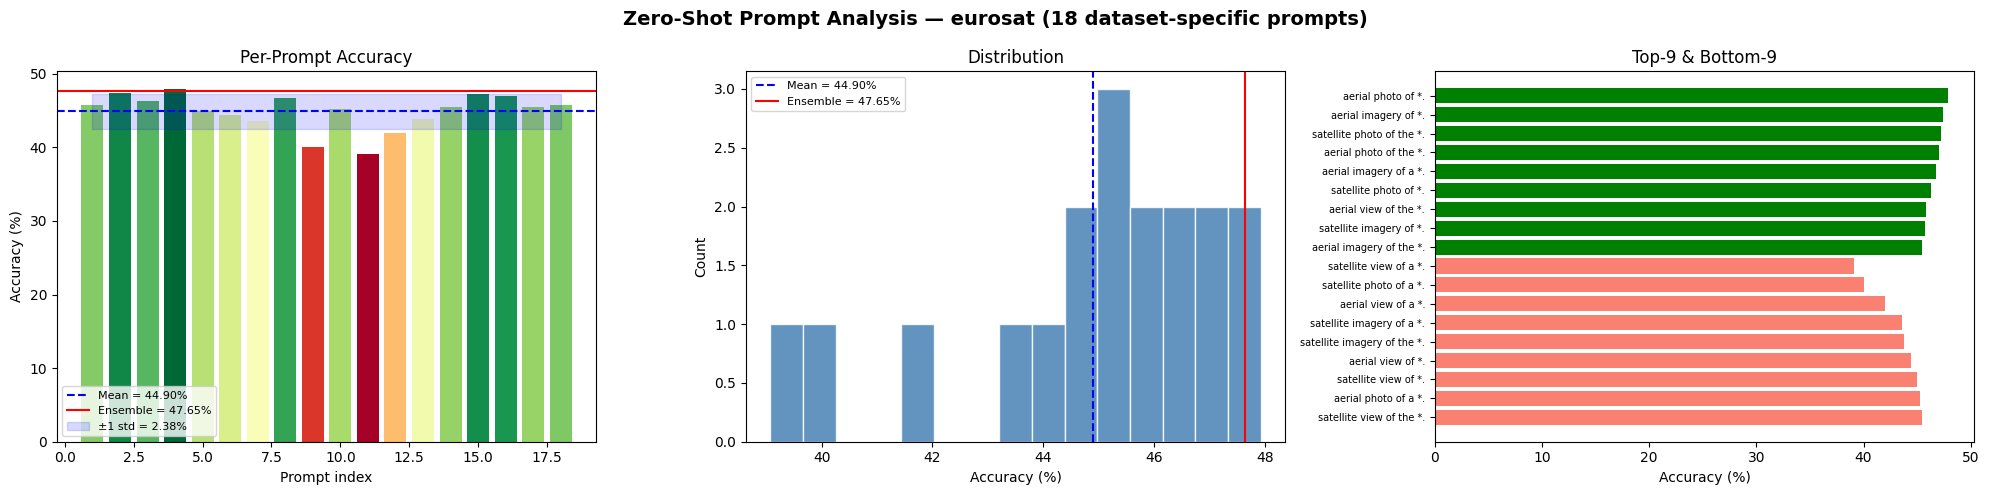

→ zeroshot_prompt_outputs/zeroshot_prompts_eurosat.png


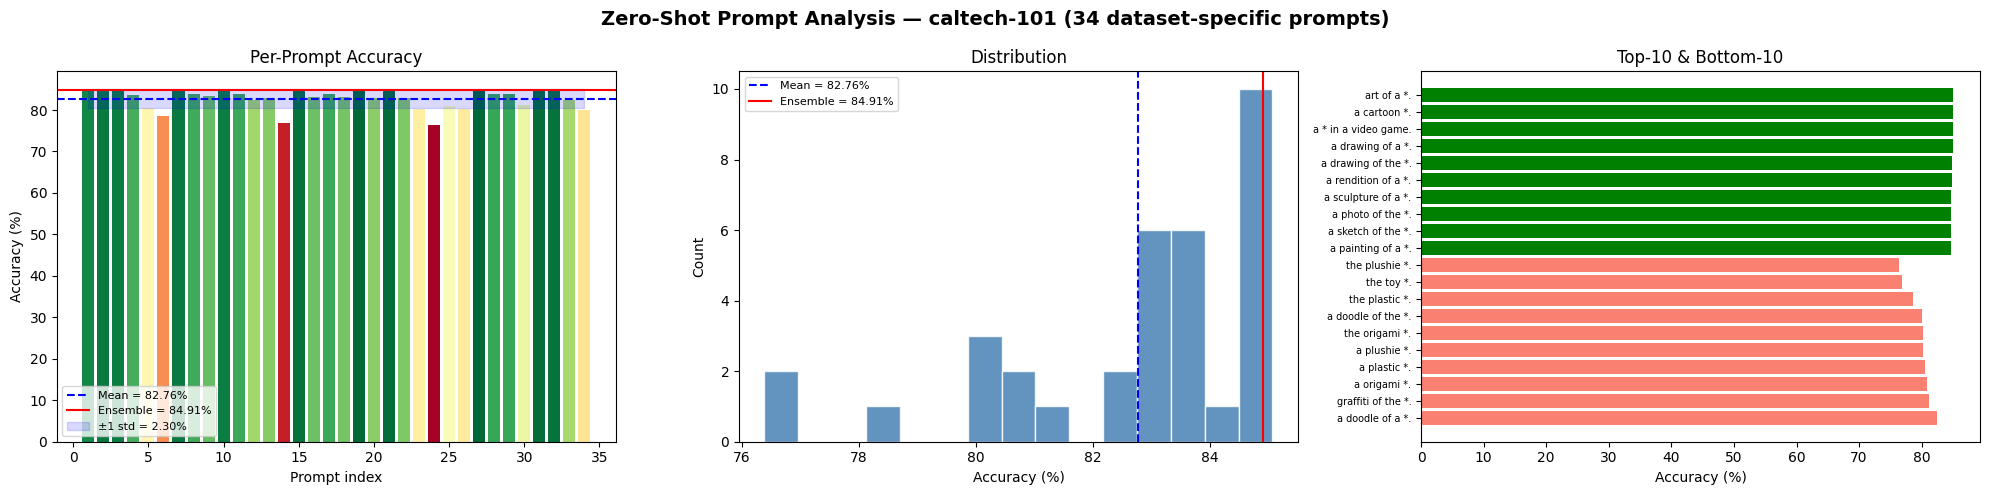

→ zeroshot_prompt_outputs/zeroshot_prompts_caltech-101.png
oxford_pets: 1 prompt(s), accuracy = 88.43% — single prompt, no variance


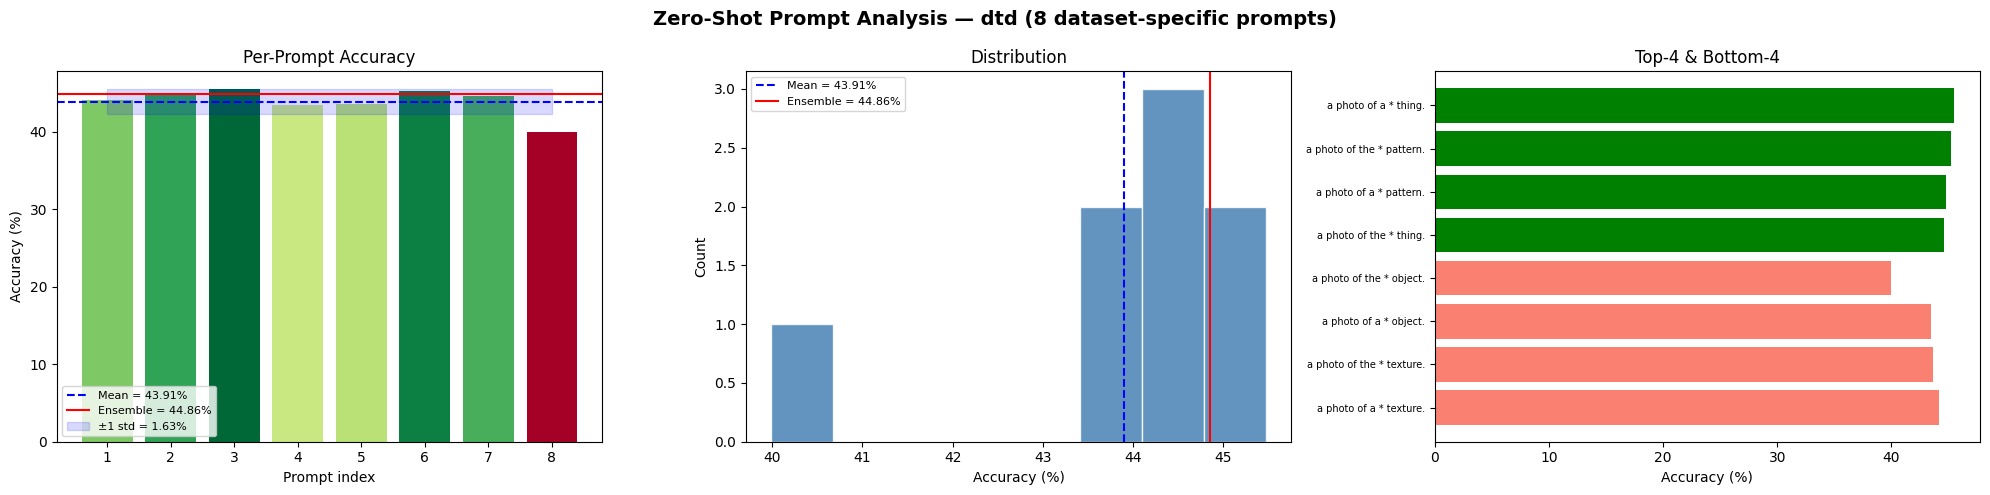

→ zeroshot_prompt_outputs/zeroshot_prompts_dtd.png
flowers102: 1 prompt(s), accuracy = 70.89% — single prompt, no variance
food101: 1 prompt(s), accuracy = 85.90% — single prompt, no variance


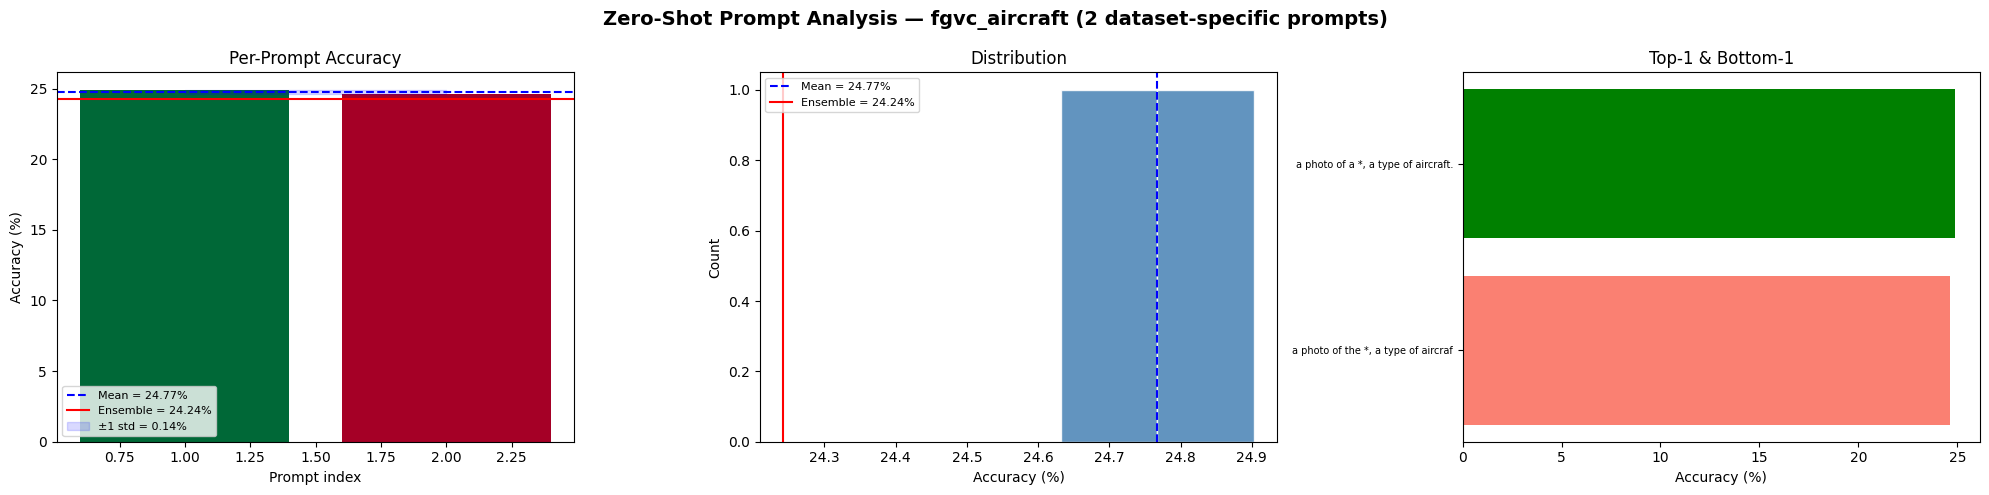

→ zeroshot_prompt_outputs/zeroshot_prompts_fgvc_aircraft.png


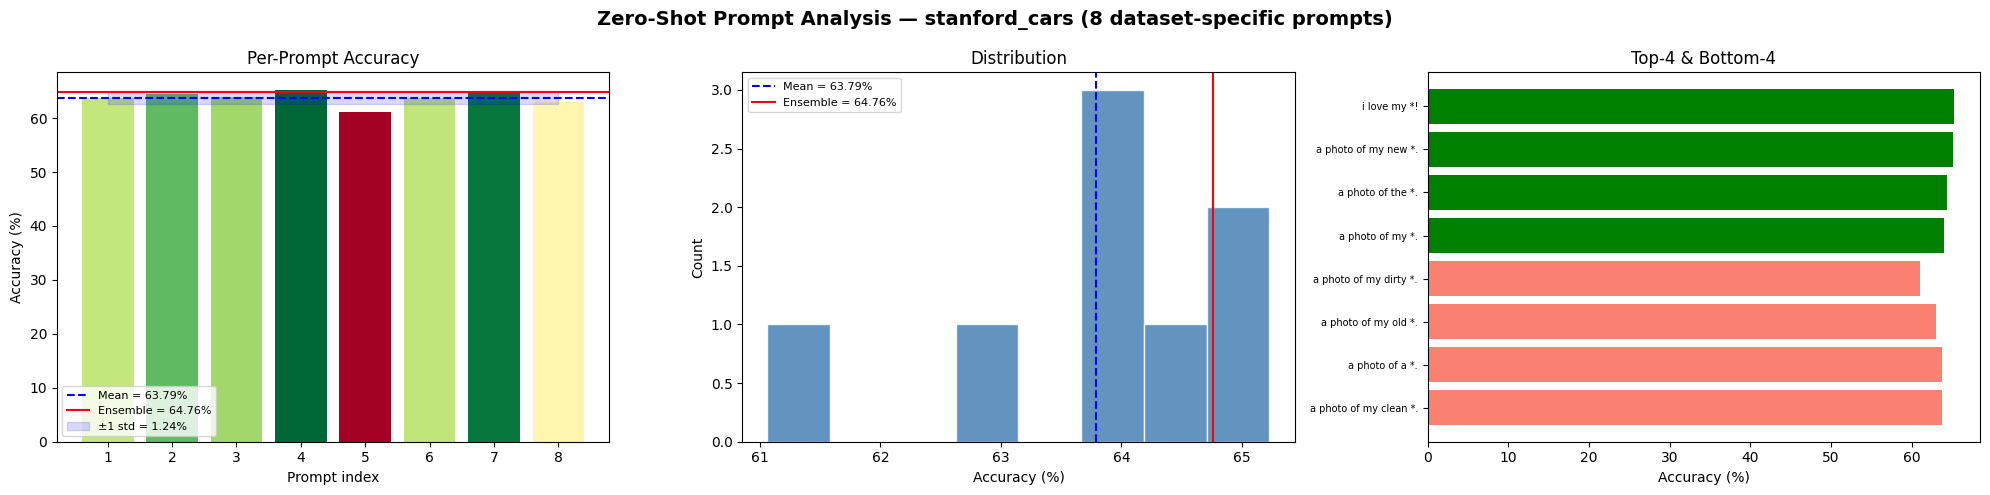

→ zeroshot_prompt_outputs/zeroshot_prompts_stanford_cars.png


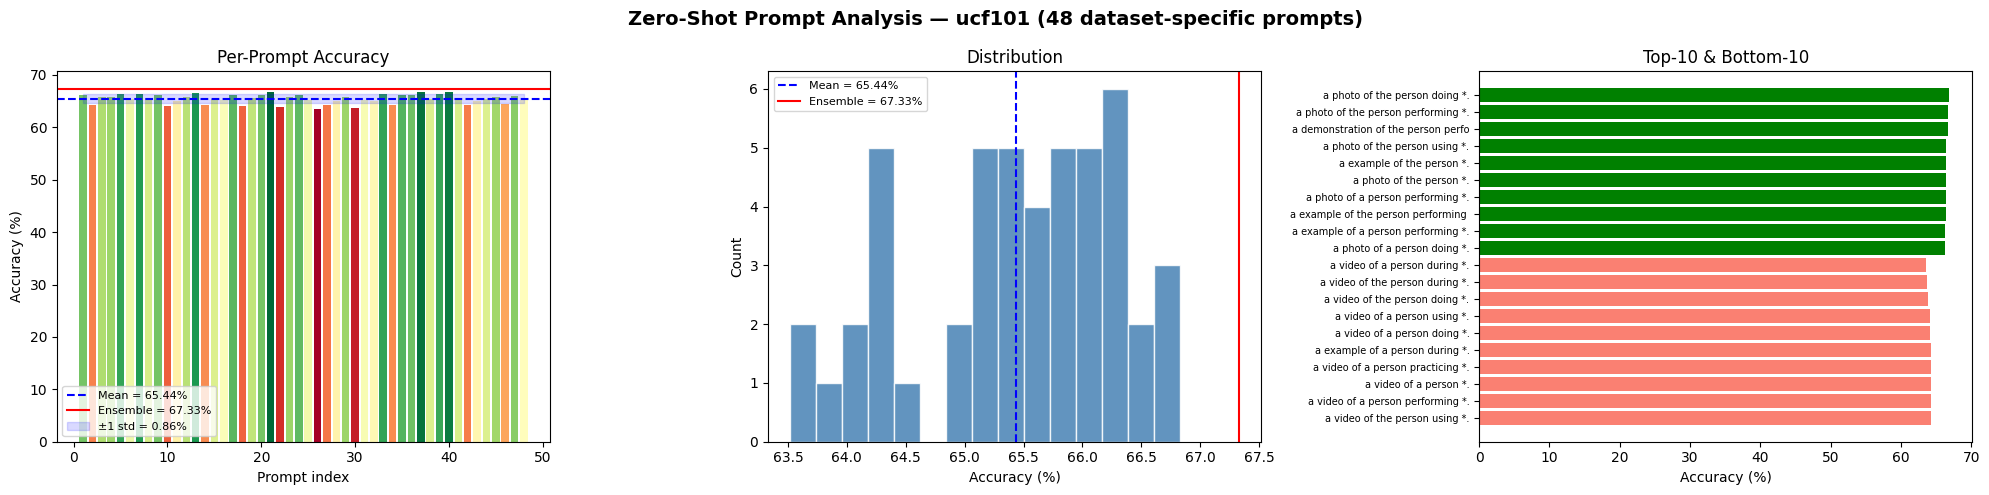

→ zeroshot_prompt_outputs/zeroshot_prompts_ucf101.png


In [8]:
os.makedirs('zeroshot_prompt_outputs', exist_ok=True)

for ds_name, res in all_prompt_results.items():
    accs = res['accuracies']
    ensemble_acc = res['ensemble_acc']
    n_prompts = res['n_prompts']

    if not res['has_variance']:
        print(f"{ds_name}: {n_prompts} prompt(s), accuracy = {accs[0]*100:.2f}% — single prompt, no variance")
        continue

    mean_acc, std_acc = res['mean'], res['std']
    min_acc, max_acc = accs.min(), accs.max()
    ds_prompts = PROMPTS_BY_DATASET[ds_name]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Zero-Shot Prompt Analysis — {ds_name} ({n_prompts} dataset-specific prompts)",
                 fontsize=14, fontweight='bold')

    # Plot 1: Bar chart
    ax = axes[0]
    colors = plt.cm.RdYlGn((accs - min_acc) / (max_acc - min_acc + 1e-8))
    ax.bar(range(1, n_prompts+1), accs*100, color=colors, edgecolor="none", width=0.8)
    ax.axhline(y=mean_acc*100, color="blue", linestyle="--", lw=1.5, label=f"Mean = {mean_acc*100:.2f}%")
    ax.axhline(y=ensemble_acc*100, color="red", linestyle="-", lw=1.5, label=f"Ensemble = {ensemble_acc*100:.2f}%")
    ax.fill_between(range(1, n_prompts+1), (mean_acc-std_acc)*100, (mean_acc+std_acc)*100,
                    alpha=0.15, color="blue", label=f"±1 std = {std_acc*100:.2f}%")
    ax.set_xlabel("Prompt index"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("Per-Prompt Accuracy"); ax.legend(loc="lower left", fontsize=8)

    # Plot 2: Histogram
    ax = axes[1]
    ax.hist(accs*100, bins=min(15, n_prompts), color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(x=mean_acc*100, color="blue", linestyle="--", lw=1.5, label=f"Mean = {mean_acc*100:.2f}%")
    ax.axvline(x=ensemble_acc*100, color="red", linestyle="-", lw=1.5, label=f"Ensemble = {ensemble_acc*100:.2f}%")
    ax.set_xlabel("Accuracy (%)"); ax.set_ylabel("Count")
    ax.set_title("Distribution"); ax.legend(fontsize=8)

    # Plot 3: Top/Bottom
    ax = axes[2]
    n_show = min(10, n_prompts // 2)
    if n_show >= 1:
        sorted_idx = np.argsort(accs)
        bottom, top = sorted_idx[:n_show], sorted_idx[-n_show:][::-1]
        show_idx = np.concatenate([top, bottom])
        show_acc = accs[show_idx] * 100
        show_labels = [ds_prompts[j].replace("{}", "*")[:35] for j in show_idx]
        bar_colors = ["green"] * n_show + ["salmon"] * n_show
        ax.barh(range(len(show_idx)), show_acc, color=bar_colors, edgecolor="none")
        ax.set_yticks(range(len(show_idx))); ax.set_yticklabels(show_labels, fontsize=7)
        ax.set_xlabel("Accuracy (%)"); ax.set_title(f"Top-{n_show} & Bottom-{n_show}")
        ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(f'zeroshot_prompt_outputs/zeroshot_prompts_{ds_name}.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f'→ zeroshot_prompt_outputs/zeroshot_prompts_{ds_name}.png')


## Cross-Dataset Comparison Chart

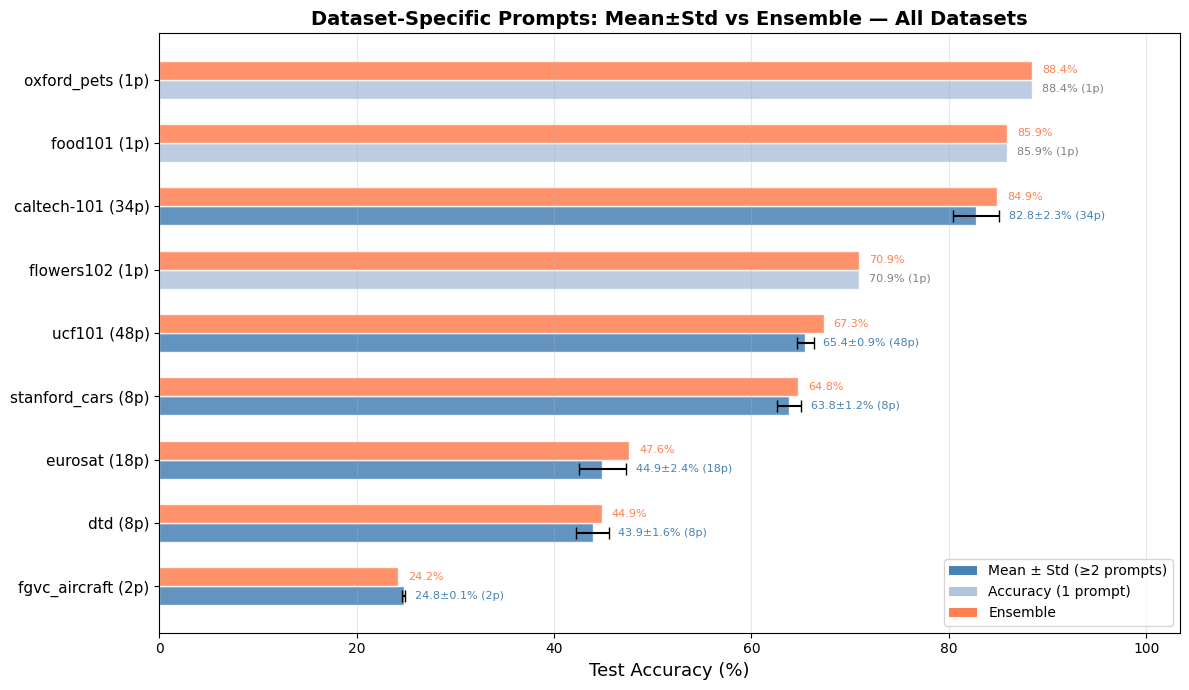

→ zeroshot_prompt_outputs/zeroshot_prompt_comparison.png


In [9]:
from matplotlib.patches import Patch

ds_names = list(all_prompt_results.keys())
means = [all_prompt_results[d]['mean']*100 for d in ds_names]
stds = [all_prompt_results[d]['std']*100 for d in ds_names]
ensembles = [all_prompt_results[d]['ensemble_acc']*100 for d in ds_names]
n_list = [all_prompt_results[d]['n_prompts'] for d in ds_names]
has_var = [all_prompt_results[d]['has_variance'] for d in ds_names]

sorted_idx = np.argsort(means)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(ds_names))

for j, idx in enumerate(sorted_idx):
    d, m, s, e, n, hv = ds_names[idx], means[idx], stds[idx], ensembles[idx], n_list[idx], has_var[idx]
    if hv:
        ax.barh(j-0.15, m, height=0.3, xerr=s, color='steelblue', edgecolor='white', capsize=4, alpha=0.85)
        ax.text(m+s+1, j-0.15, f'{m:.1f}±{s:.1f}% ({n}p)', va='center', fontsize=8, color='steelblue')
    else:
        ax.barh(j-0.15, m, height=0.3, color='lightsteelblue', edgecolor='white', alpha=0.85)
        ax.text(m+1, j-0.15, f'{m:.1f}% ({n}p)', va='center', fontsize=8, color='gray')
    ax.barh(j+0.15, e, height=0.3, color='coral', edgecolor='white', alpha=0.85)
    ax.text(e+1, j+0.15, f'{e:.1f}%', va='center', fontsize=8, color='coral')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{ds_names[i]} ({n_list[i]}p)' for i in sorted_idx], fontsize=11)
ax.set_xlabel('Test Accuracy (%)', fontsize=13)
ax.set_title('Dataset-Specific Prompts: Mean±Std vs Ensemble — All Datasets', fontsize=14, fontweight='bold')
ax.legend(handles=[
    Patch(facecolor='steelblue', label='Mean ± Std (≥2 prompts)'),
    Patch(facecolor='lightsteelblue', label='Accuracy (1 prompt)'),
    Patch(facecolor='coral', label='Ensemble'),
], loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(max(means), max(ensembles)) + 15)
plt.tight_layout()
plt.savefig('zeroshot_prompt_outputs/zeroshot_prompt_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('→ zeroshot_prompt_outputs/zeroshot_prompt_comparison.png')


## Summary Table

In [10]:
rows = []
for ds_name, res in all_prompt_results.items():
    row = {'Dataset': ds_name, 'N Prompts': res['n_prompts'],
           'Ensemble (%)': round(res['ensemble_acc']*100, 2)}
    if res['has_variance']:
        row.update({'Mean (%)': round(res['mean']*100, 2), 'Std (%)': round(res['std']*100, 2),
                    'Variance': round(res['var'], 6),
                    'Min (%)': round(res['accuracies'].min()*100, 2),
                    'Max (%)': round(res['accuracies'].max()*100, 2)})
    else:
        row.update({'Mean (%)': round(res['mean']*100, 2), 'Std (%)': '—',
                    'Variance': '—', 'Min (%)': '—', 'Max (%)': '—'})
    rows.append(row)
df = pd.DataFrame(rows).sort_values('Ensemble (%)', ascending=False).reset_index(drop=True)
df.to_csv('zeroshot_prompt_outputs/zeroshot_prompt_summary.csv', index=False)
print(df.to_string(index=False))
display(df)


      Dataset  N Prompts  Ensemble (%)  Mean (%) Std (%)  Variance Min (%) Max (%)
  oxford_pets          1         88.43     88.43       —         —       —       —
      food101          1         85.90     85.90       —         —       —       —
  caltech-101         34         84.91     82.76     2.3  0.000527   76.38   85.07
   flowers102          1         70.89     70.89       —         —       —       —
       ucf101         48         67.33     65.44    0.86  0.000074   63.52   66.83
stanford_cars          8         64.76     63.79    1.24  0.000153   61.06   65.23
      eurosat         18         47.65     44.90    2.38  0.000565   39.07   47.93
          dtd          8         44.86     43.91    1.63  0.000264   39.98   45.48
fgvc_aircraft          2         24.24     24.77    0.14  0.000002   24.63    24.9


,Dataset,N Prompts,Ensemble (%),Mean (%),Std (%),Variance,Min (%),Max (%)
0,oxford_pets,1,88.43,88.43,—,—,—,—
1,food101,1,85.90,85.90,—,—,—,—
2,caltech-101,34,84.91,82.76,2.3,0.000527,76.38,85.07
3,flowers102,1,70.89,70.89,—,—,—,—
4,ucf101,48,67.33,65.44,0.86,0.000074,63.52,66.83
5,stanford_cars,8,64.76,63.79,1.24,0.000153,61.06,65.23
6,eurosat,18,47.65,44.90,2.38,0.000565,39.07,47.93
7,dtd,8,44.86,43.91,1.63,0.000264,39.98,45.48
8,fgvc_aircraft,2,24.24,24.77,0.14,0.000002,24.63,24.9


In [11]:
for ds_name, res in all_prompt_results.items():
    ds_prompts = PROMPTS_BY_DATASET[ds_name]
    pd.DataFrame({
        'prompt_index': range(1, len(res['accuracies'])+1),
        'template': ds_prompts,
        'accuracy': res['accuracies'],
    }).to_csv(f'zeroshot_prompt_outputs/zeroshot_{ds_name}_per_prompt.csv', index=False)
print(f"Saved per-prompt CSVs for {len(all_prompt_results)} datasets")


Saved per-prompt CSVs for 9 datasets


## Download All Results

In [12]:
import glob
from google.colab import files

zip_name = 'zeroshot_prompt_analysis_all.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(glob.glob('zeroshot_prompt_outputs/*')):
        zf.write(f, os.path.basename(f))
print(f'→ {zip_name} ({os.path.getsize(zip_name)/1024:.1f} KB)')
files.download(zip_name)


→ zeroshot_prompt_analysis_all.zip (728.8 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>